[ 368.93205743  384.33989278  407.45164579  780.35214106  477.15642317
    0.            0.            0.            0.            0.
    0.         -294.3        -490.5           0.            0.
    1.18609572   -2.3111753     0.            0.        ]
[ 0.          0.          1.18609572 -2.3111753   0.          0.
  0.          0.        ]


C:\Users\marko\AppData\Local\Temp\ipykernel_21952\3145502689.py:249: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#controlling-the-legend-entries
  plt.legend('Sum of torque','rate of change of angmom')
C:\Users\marko\AppData\Local\Temp\ipykernel_21952\3145502689.py:256: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#controlling-the-legend-entries
  plt.legend('Sum of torque','rate of change of angmom')
C:\Users\marko\AppData\Local\Temp\ipykernel_21952\3145502689.py:263: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#controlling-the-legend-entries
  plt.legend('Sum of torque integral','Change of angmom')


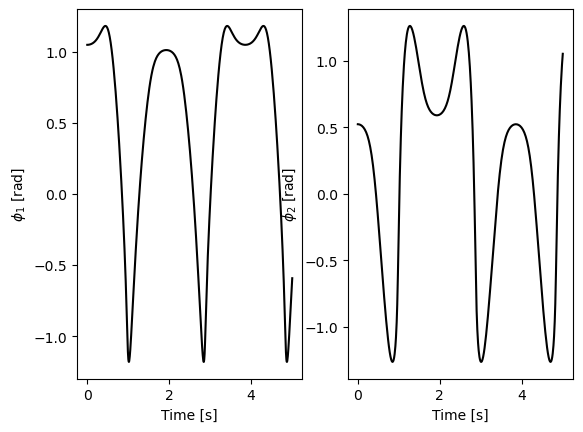

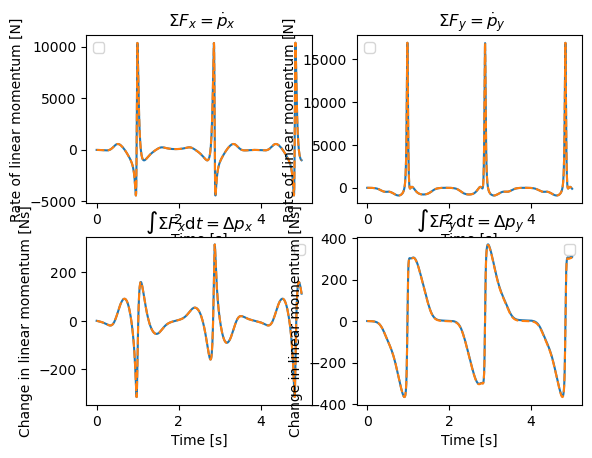

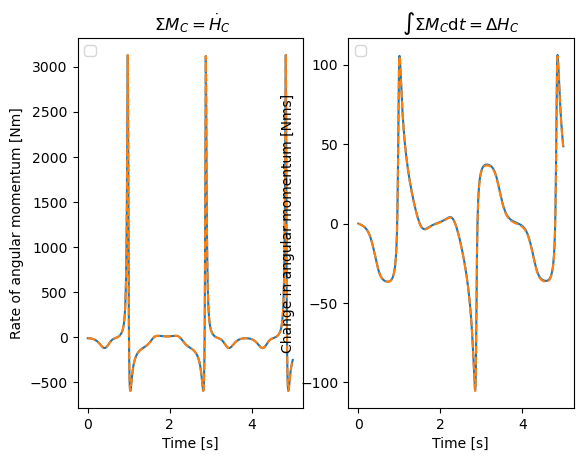

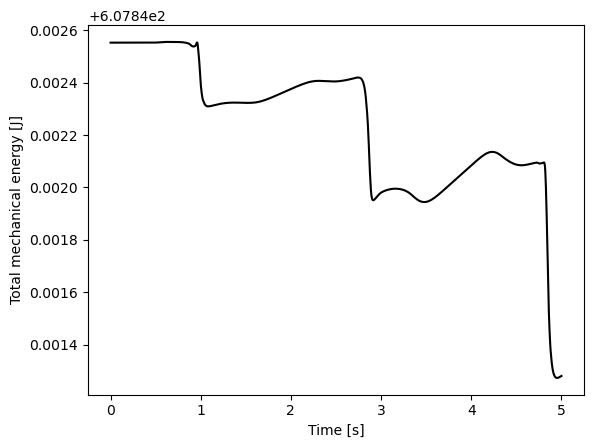

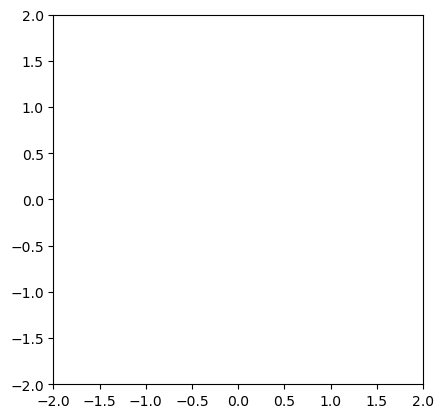

In [4]:
# -*- coding: utf-8 -*-
"""
Program to test the functionalities in the segdyn module in a forward simulation

@author: Koen Lemaire
"""
#%% import segdyn
import segdyn
import scipy as sp
import scipy.integrate 
import scipy.signal
import scipy.linalg
import numpy as np
import matplotlib.pyplot as plt

#%% test segdyn -- double pendulum forward simulation, no input
def segdynshell_doublepend(t,state,u0,parms):
    """
    segdynstated, Vnew = segdynshell_forward(t,segdynstate,segparms)
    
    Shell function around segdyn (see documentation in segdyn for details).
    segdynshell represents a set of ODE's that can be integrated with solve_ivp
    or similar. In segdynshell the dynamics of the 2D rigid body linkage are 
    defined through the vector V (see segdyn for details). Time dependent 
    inputs, external forces and constraints are also defined in this function.
    Note that for pure inverse applications where no simulation is required,
    segdyn should be callled directly. 
                          
    INPUT 
    t:        time (s)
    
    state:    vector containing segdynstate (see segdyn for definition) and any
              other state variables contained in the model
              
    segparms: dictionary with fields: 
              L=[l_1 .. l_n], d=[d_1 .. d_n], m=[m_1 .. m_n], and J=[J_1 .. J_n], where
              L_i is the length of the ith segment (m), d_i is the distance from the
              proximal end of the ith segment to its center of gravity (m), m_i is the
              mass of the ith segment (kg), and J_i the moment of inertia of the ith
              segment with respect to its center of gravity (kgm**2) 
              
    OUTPUT 

    stated:   first order derivative of state
    Vnew:     copy of V, with all unknown variables replaced with the value resulting
              from solving the equations of motion (see segdyn)
                 
   Author: Koen Lemaire (k.k.lemaire2@vu.nl)  
   """
    # read out parameters 
    segparms=parms['segparms']
    nseg=segparms['nseg']
    m=segparms['m']
    L=segparms['L']
    J=segparms['J']
    d=segparms['d']
   
   # Unravel state vector
    segdynstate=state # only in case the model has no other state variables
    phi=segdynstate[0:nseg]
    phid=segdynstate[nseg:2*nseg]
    xb=segdynstate[2*nseg:2*nseg+1]
    yb=segdynstate[2*nseg+1:2*nseg+2]
    xbd=segdynstate[2*nseg+2:2*nseg+3]
    ybd=segdynstate[2*nseg+3:2*nseg+4]
        
    # Application specific: external forces and moments
    Fexty=m*g # gravity
    
    # application specific: time variant input moments / forces
    
    
    # Define V: this is where the basic dynamics are defined
    # Below we define the vector V, containing all (7*nseg+5) variables that could
    # potentially appear as unknowns in the equations of motion of a rigid body  
    # linkage (see definition and order of variables in comments behind each line).
    # Exactly 4*nseg+5 of these variables must contain an appropriate (known) 
    # value, the other 3*nseg variables must contain a np.nan (unknown) value.
    V=np.array(
        [np.nan, np.nan, 0, # Fx nseg+1 horizontal joint reaction forces
         np.nan, np.nan, 0, # Fy nseg+1 vertical joint reaction forces
         u0[0], u0[1], 0, # M nseg+1 net joint moments
         0, 0, # Fextx nseg horizontal external forces
         Fexty[0], Fexty[1], # Fexty nseg vertical externalforces
         0, 0, # Mext nseg external moments
         np.nan, np.nan, # phidd nseg segment angular accelerations
         0, 0], # [xbdd ybdd] horizontal and vertical base acceleration
         dtype=float) # make sure to cast as float (even when all input are int)
    
    # call without constraints
    # segdynstated, Vnew = segdyn.segdyn(segdynstate,segparms,V,Acons=None,Bcons=None)  
    
    
    # Application specific: constraints
    # to add a constraint, first define the constraint at the postion level, 
    # then differentiate wrt time twice and construct Acons and Bcons such that
    # Acons@V=Bcons represents the twice differentiated constraint equation. 
    # Each contraint at the positinonal level corresponds to one row in Acons 
    # and Bcons. Thus Acons.shape=(n_constraints,7*nseg+5) and
    # Bcons.shape=(n_constraints,). After defining Acons and Bcons, make the 
    # appropriate values in V unknown (ie nan), such that:
    # n_constraints + 3*nseg = n_unknowns
    
    # define Acons and Bcons:
    # constraint equation such that x coordinate endpoint has acceleration 0
    Acons=np.zeros(7*nseg+5) # initialize    
    Acons[-4:] = [-L[0]*np.sin(phi[0]), -L[1]*np.sin(phi[1]), 1, 0]    
    Bcons = np.array([L[0]*np.cos(phi[0])*phid[0]**2 + L[1]*np.cos(phi[1])*phid[1]**2])
    
    # update V in case of contraints:
    V[2] = np.nan # x reaction force at end of chain unknown    
    
    # calculate segdynstated and Vnew:
    segdynstated, Vnew = segdyn.segdyn(segdynstate,segparms,V,Acons=Acons,Bcons=Bcons)  
    
    # calculate other state derivative values (if needed):
        
    
    # define stated:
    stated=segdynstated # in case no other states present
    
    return stated, Vnew

# start with clean sheet
plt.close('all')

# define parms (approximately a person with lower legs, upper legs, HAT)
nseg=2
m=np.array([30, 50])
L=np.array([0.9, 0.8])
J=np.array([2, 3])
d=np.array([0.5, 0.4])
g=-9.81
phi=[np.pi/3, np.pi/6]
phid=[0, 0]
base=[0, 0]
based=[0, 0]
u0=[0, 0]

state0=np.concatenate((phi, phid, base, based))

# segment parameters
segparms = {'nseg':nseg, # number of segments
            'm':m, # mass of each segment [kg]
            'L':L, # length of each segment [m]           
            'd':d, # distance of COM of segment from proximal joint [m]
            'J':J, # moment of inertia about COM of segment [kgm**2]
            'g':g} # gravitational acceleration [m/s**2]

parms = {'segparms': segparms}

# test segdynshell
stated0, out0 = segdynshell_doublepend(0, state0, u0, parms)
print(out0)
print(stated0)

# do simulation
t_span=[0, 5]
#time_base=np.linspace(0, 5, 5000)
odefun= lambda t,state: segdynshell_doublepend(t, state, u0, parms)[0]
sol=sp.integrate.solve_ivp(odefun,t_span,state0,rtol=1e-8,atol=1e-8)#,t_eval=time_base)
t=sol.t
state=sol.y
segdynstate=state
# obtain output
stated=np.zeros((len(stated0),len(t)))
V=np.zeros((len(out0),len(t)))
for i in range(len(t)):
    stated[:,i], V[:,i] =segdynshell_doublepend(t[i],state[:,i],u0,parms)

segdynstated=stated
# unravel state vector
phi=segdynstate[0:nseg]
phid=segdynstate[nseg:2*nseg]
xb=segdynstate[2*nseg:2*nseg+1]
yb=segdynstate[2*nseg+1:2*nseg+2]
xbd=segdynstate[2*nseg+2:2*nseg+3]
ybd=segdynstate[2*nseg+3:2*nseg+4]

# unravel output:
n=nseg
Fxr   = V[0     : n+1]    # nseg+1 horizontal joint reaction forces
Fyr   = V[n+1   : 2*n+2]  # nseg+1 vertical joint reaction forces
M     = V[2*n+2 : 3*n+3]  # nseg+1 net joint moments
Fxext = V[3*n+3 : 4*n+3]  # nseg horizontal external forces
Fyext = V[4*n+3 : 5*n+3]  # nseg vertical externalforces
Mext  = V[5*n+3 : 6*n+3]  # nseg external moments
phidd = V[6*n+3 : 7*n+3]  # nseg segment angular accelerations
xbdd  = V[7*n+3 : 7*n+4]  # horizontal base acceleration
ybdd  = V[7*n+4 : 7*n+5]  # vertical base acceleration

# get segcom and totcom positions and velocities
_, _, _, totcom, totcomd, totcomdd = segdyn.comcoord(segdynstate,segparms, segdynstated)
totcomx,totcomy=totcom
totcomxd,totcomyd=totcomd
totcomxdd,totcomydd=totcomdd

# get joint coordinates
joint, joind, jointdd = segdyn.jointcoord(segdynstate, segparms, segdynstated)
jointx,jointy=joint

# Linear momentum balance:
# sum of forces, lhs:
sumFx = Fxr[0] - Fxr[2]+np.sum(Fxext, axis=0)
sumFy = Fyr[0] - Fyr[2]+np.sum(Fyext, axis=0)
sumFx_dt = sp.integrate.cumulative_trapezoid(sumFx, t, initial = (0))
sumFy_dt = sp.integrate.cumulative_trapezoid(sumFy, t, initial = (0))

# linear momentum of CoM, rhs:
linmomx=np.sum(m)*totcomxd
linmomy=np.sum(m)*totcomyd
linmomx-=linmomx[0] # substract first value to get change
linmomy-=linmomy[0]
linmomxd=np.sum(m)*totcomxdd
linmomyd=np.sum(m)*totcomydd

# Angular momentum balance:
# moment of ground reaction force and constraint force wrt total body CoM, lhs:
M_ground=(xb-totcomx)*Fyr[0]-(yb-totcomy)*Fxr[0] # moment of ground reaction force
M_Fconstraint=(jointx[2]-totcomx)*-Fyr[2] - (jointy[2]-totcomy)*-Fxr[2] # moment of constraint force
Mext_tot=M_ground+M_Fconstraint
Mext_tot_dt=sp.integrate.cumulative_trapezoid(Mext_tot,t,initial=(0)) # time integral of moment of ground reaction force
# angular momentum wrt to total body CoM, rhs:
angmom,angmomd = segdyn.angmom(segdynstate,segparms,segdynstated=segdynstated)
angmom -= angmom[0] # subtract first value to have change

# Energy balance, sum of segment energies and gravitational potential energy:
Ekinx, Ekiny, Erot, Epot, Etot = segdyn.energy(state,segparms)

# plot states
plt.figure()
plt.subplot(1,2,1)
plt.plot(t,state[0,:],'k')
plt.xlabel('Time [s]')
plt.ylabel('$\phi_1$ [rad]')

plt.subplot(1,2,2)
plt.plot(t,state[1,:],'k')
plt.xlabel('Time [s]')
plt.ylabel('$\phi_2$ [rad]')

# plot linear momentum balance
plt.figure()
plt.subplot(2,2,1)
plt.plot(t,sumFx.T,t,linmomxd,'--')
plt.title(' $\Sigma F_x = \dot{p}_{x}$')
plt.xlabel('Time [s]')
plt.ylabel('Rate of linear momentum [N]')
plt.legend('Sum of torque','rate of change of angmom')

plt.subplot(2,2,2)
plt.plot(t,sumFy.T,t,linmomyd,'--')
plt.title(' $\Sigma F_y = \dot{p}_{y}$')
plt.xlabel('Time [s]')
plt.ylabel('Rate of linear momentum [N]')
plt.legend('Sum of torque','rate of change of angmom')

plt.subplot(2,2,3)
plt.plot(t,sumFx_dt.T,t,linmomx,'--')
plt.title('$\int \Sigma F_x \mathrm{d}t = \Delta p_x$')
plt.xlabel('Time [s]')
plt.ylabel('Change in linear momentum [Ns]')
plt.legend('Sum of torque integral','Change of angmom')

plt.subplot(2,2,4)
plt.plot(t,sumFy_dt.T,t,linmomy,'--')
plt.title('$\int \Sigma F_y \mathrm{d}t = \Delta p_y$')
plt.xlabel('Time [s]')
plt.ylabel('Change in linear momentum [Ns]')
plt.legend('Sum of torque integral','Change of angmom')

# plot angular momentum balance
plt.figure()
plt.subplot(1,2,1)
plt.plot(t,Mext_tot.T,t,angmomd,'--')
plt.title(' $\Sigma M_C = \dot{H}_{C}$')
plt.xlabel('Time [s]')
plt.ylabel('Rate of angular momentum [Nm]')
plt.legend('Sum of torque','rate of change of angmom')

plt.subplot(1,2,2)
plt.plot(t,Mext_tot_dt.T,t,angmom,'--')
plt.title('$\int \Sigma M_C \mathrm{d}t = \Delta H_C$')
plt.xlabel('Time [s]')
plt.ylabel('Change in angular momentum [Nms]')
plt.legend('Sum of torque integral','Change of angmom')

# plot energies
plt.figure()
plt.plot(sol.t,Etot,'k')
plt.xlabel('Time [s]')
plt.ylabel('Total mechanical energy [J]')

import matplotlib.animation as animation
# animation
anim=segdyn.animate(t,state,segparms)
writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
anim.save('Exportfiles/Two_stick_pendulum.gif', writer=writer)


# %%
